In [3]:
import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sns

In [4]:
import os
os.getcwd()

'/content'

In [5]:
df = pd.read_csv("/content/StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [6]:
df.tail()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77
999,female,group D,some college,free/reduced,none,77,86,86


In [7]:

df.shape

(1000, 8)

In [8]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [10]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [11]:
df.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


In [12]:
df.isnull().sum().sum()

np.int64(0)

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
categorical_columns = [
    "gender",
    "race/ethnicity",
    "parental level of education",
    "lunch",
    "test preparation course"
]

In [15]:
for column in categorical_columns:
    print("\n", column)
    print(df[column].unique())


 gender
['female' 'male']

 race/ethnicity
['group B' 'group C' 'group A' 'group D' 'group E']

 parental level of education
["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']

 lunch
['standard' 'free/reduced']

 test preparation course
['none' 'completed']


In [16]:
for column in categorical_columns:
    print("\n", column)
    print(df[column].value_counts())


 gender
gender
female    518
male      482
Name: count, dtype: int64

 race/ethnicity
race/ethnicity
group C    319
group D    262
group B    190
group E    140
group A     89
Name: count, dtype: int64

 parental level of education
parental level of education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64

 lunch
lunch
standard        645
free/reduced    355
Name: count, dtype: int64

 test preparation course
test preparation course
none         642
completed    358
Name: count, dtype: int64


In [17]:
score_columns = [
    "math score",
    "reading score",
    "writing score"
]

In [18]:
print("Math Median:", df["math score"].median())
print("Reading Median:", df["reading score"].median())
print("Writing Median:", df["writing score"].median())

Math Median: 66.0
Reading Median: 70.0
Writing Median: 69.0


In [19]:
df[score_columns].std()

,0
math score,15.163080
reading score,14.600192
writing score,15.195657


In [20]:
df[score_columns].quantile([0.25, 0.50, 0.75])

,math score,reading score,writing score
0.25,57.0,59.0,57.75
0.50,66.0,70.0,69.00
0.75,77.0,79.0,79.00


In [21]:
df["Total Score"] = (
    df["math score"] +
    df["reading score"] +
    df["writing score"]
)

In [22]:

df[[
    "math score",
    "reading score",
    "writing score",
    "Total Score"
]].head()

,math score,reading score,writing score,Total Score
0,72,72,74,218
1,69,90,88,247
2,90,95,93,278
3,47,57,44,148
4,76,78,75,229


In [23]:
df["Average Score"] = df[
    ["math score", "reading score", "writing score"]
].mean(axis=1)

In [24]:

df[[
    "math score",
    "reading score",
    "writing score",
    "Average Score"
]].head()

,math score,reading score,writing score,Average Score
0,72,72,74,72.666667
1,69,90,88,82.333333
2,90,95,93,92.666667
3,47,57,44,49.333333
4,76,78,75,76.333333


In [25]:
df["Percentage Performance"] = (
    df["Total Score"] / 300
) * 100

In [26]:
df[[
    "Total Score",
    "Percentage Performance"
]].head()

,Total Score,Percentage Performance
0,218,72.666667
1,247,82.333333
2,278,92.666667
3,148,49.333333
4,229,76.333333


In [27]:
df["Pass/Fail Status"] = np.where(
    (df["math score"] >= 40) &
    (df["reading score"] >= 40) &
    (df["writing score"] >= 40),
    "Pass",
    "Fail"
)

In [28]:
df["Pass/Fail Status"].value_counts()

,count
Pass/Fail Status,
Pass,949
Fail,51


In [29]:
df[[
    "math score",
    "reading score",
    "writing score",
    "Pass/Fail Status"
]].head()

,math score,reading score,writing score,Pass/Fail Status
0,72,72,74,Pass
1,69,90,88,Pass
2,90,95,93,Pass
3,47,57,44,Pass
4,76,78,75,Pass


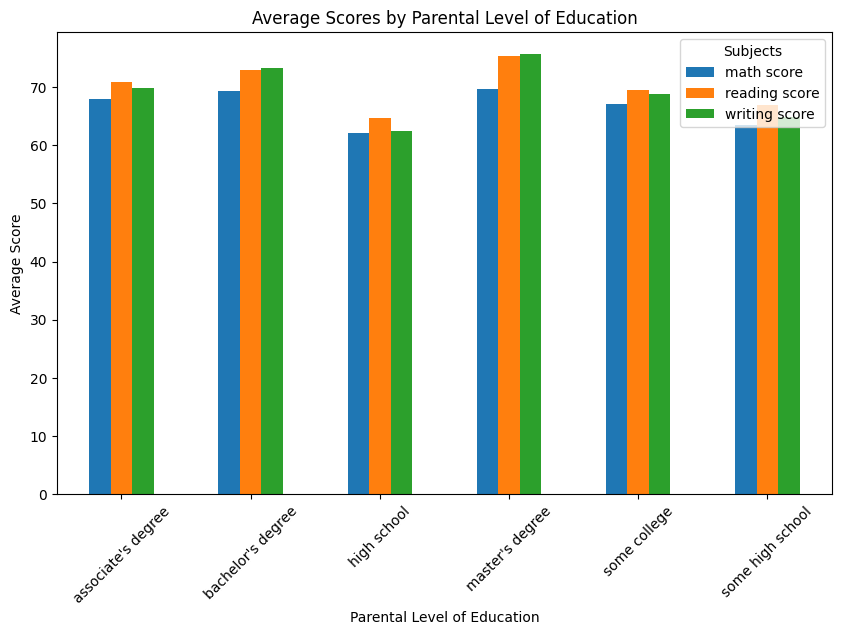

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns


parental_avg = df.groupby("parental level of education")[
    ["math score", "reading score", "writing score"]
].mean()


parental_avg.plot(kind="bar", figsize=(10, 6))

plt.title("Average Scores by Parental Level of Education")
plt.xlabel("Parental Level of Education")
plt.ylabel("Average Score")
plt.xticks(rotation=45)
plt.legend(title="Subjects")
plt.show()

In [31]:
lunch_avg = df.groupby("lunch")[
    ["math score", "reading score", "writing score"]
].mean()

print(lunch_avg)

              math score  reading score  writing score
lunch                                                 
free/reduced   58.921127      64.653521      63.022535
standard       70.034109      71.654264      70.823256


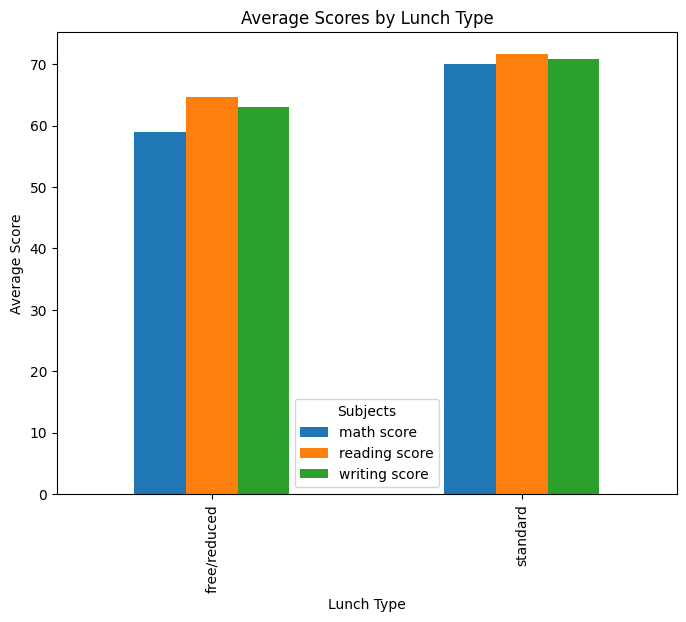

In [32]:
lunch_avg.plot(kind="bar", figsize=(8, 6))

plt.title("Average Scores by Lunch Type")
plt.xlabel("Lunch Type")
plt.ylabel("Average Score")
plt.legend(title="Subjects")
plt.show()

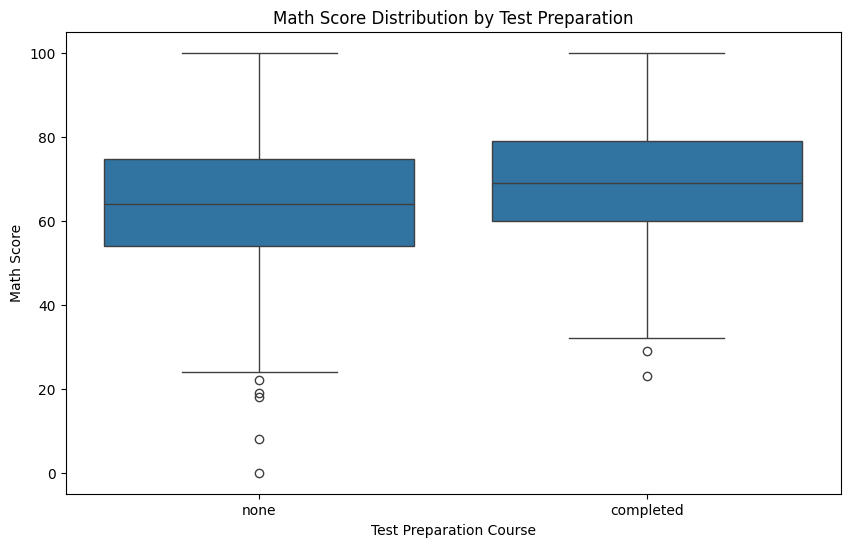

In [33]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="test preparation course",
    y="math score"
)

plt.title("Math Score Distribution by Test Preparation")
plt.xlabel("Test Preparation Course")
plt.ylabel("Math Score")
plt.show()

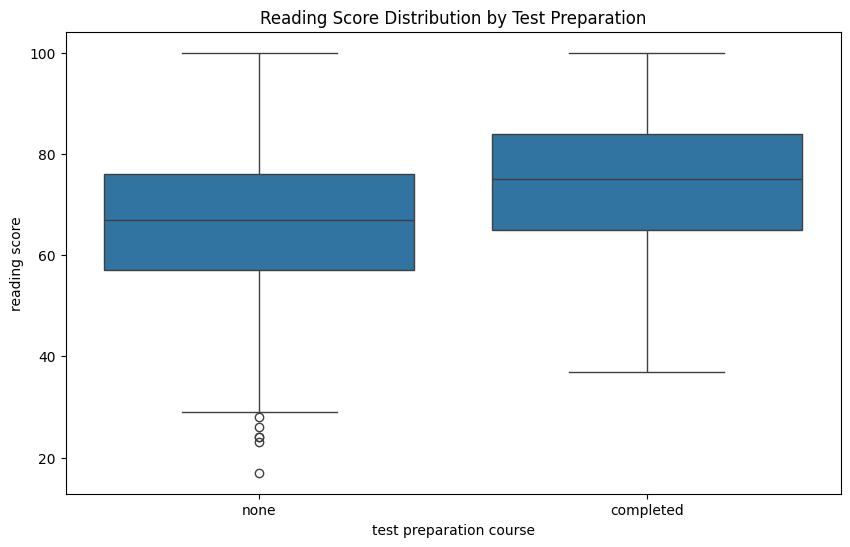

In [34]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="test preparation course",
    y="reading score"
)

plt.title("Reading Score Distribution by Test Preparation")
plt.show()

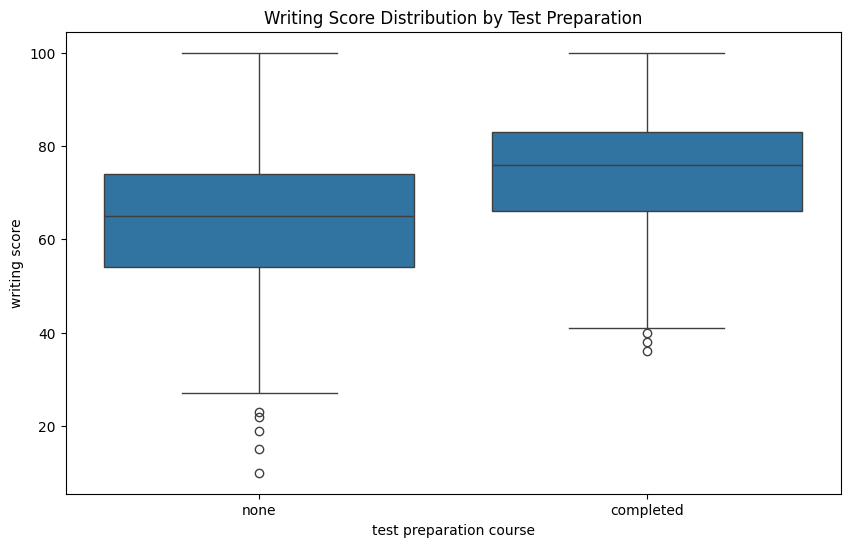

In [35]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="test preparation course",
    y="writing score"
)

plt.title("Writing Score Distribution by Test Preparation")
plt.show()

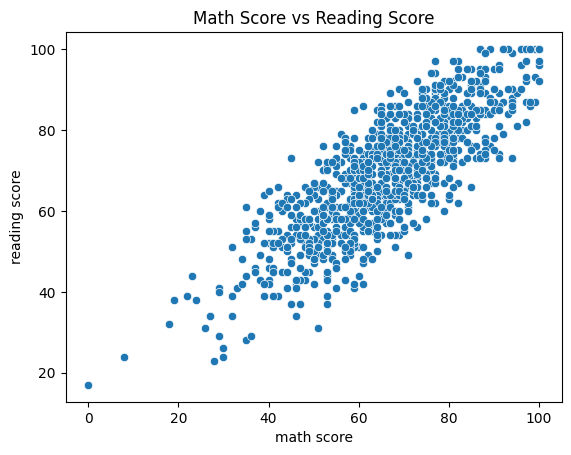

In [36]:
sns.scatterplot(
    data=df,
    x="math score",
    y="reading score"
)

plt.title("Math Score vs Reading Score")
plt.show()

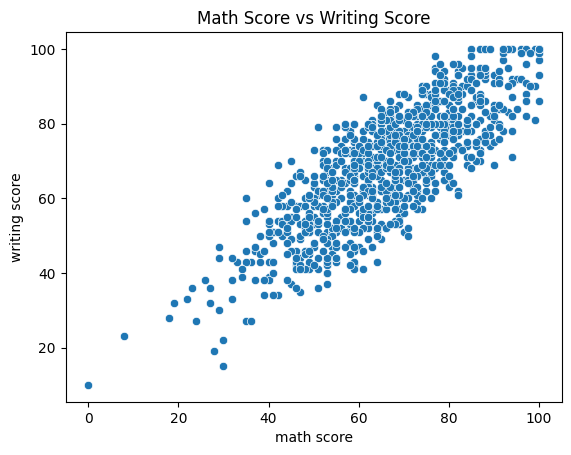

In [37]:
sns.scatterplot(
    data=df,
    x="math score",
    y="writing score"
)

plt.title("Math Score vs Writing Score")
plt.show()

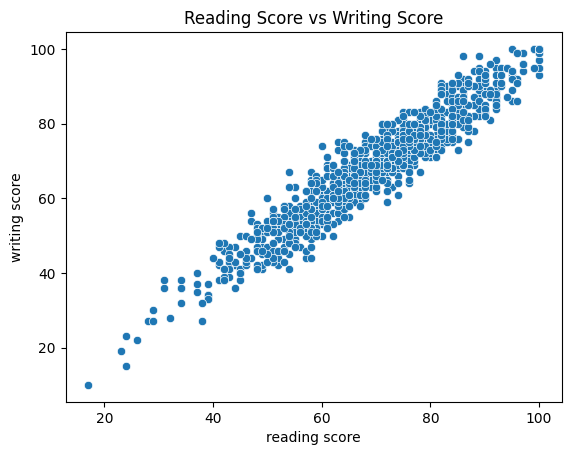

In [38]:
sns.scatterplot(
    data=df,
    x="reading score",
    y="writing score"
)

plt.title("Reading Score vs Writing Score")
plt.show()

In [39]:
subjects = ["math score", "reading score", "writing score"]

correlation = df[subjects].corr()

print(correlation)

               math score  reading score  writing score
math score       1.000000       0.817580       0.802642
reading score    0.817580       1.000000       0.954598
writing score    0.802642       0.954598       1.000000


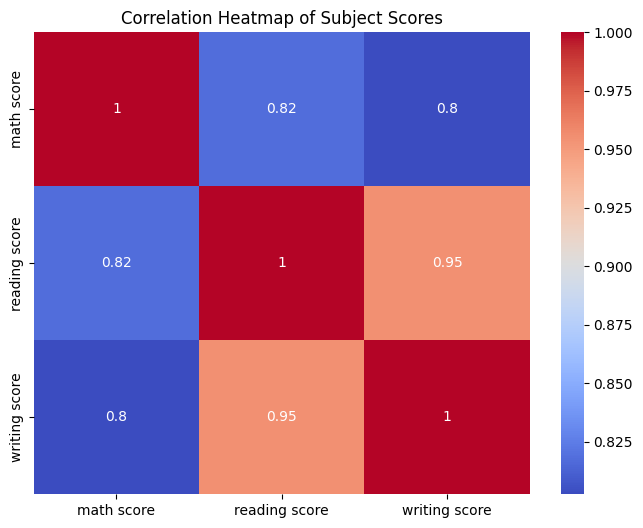

In [40]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap of Subject Scores")
plt.show()

In [41]:
test_prep_avg = df.groupby("test preparation course")[
    ["math score", "reading score", "writing score"]
].mean()

print(test_prep_avg)

                         math score  reading score  writing score
test preparation course                                          
completed                 69.695531      73.893855      74.418994
none                      64.077882      66.534268      64.504673


In [42]:
gender_avg = df.groupby("gender")[
    ["math score", "reading score", "writing score"]
].mean()

print("Average Scores by Gender:")
print(gender_avg)

Average Scores by Gender:
        math score  reading score  writing score
gender                                          
female   63.633205      72.608108      72.467181
male     68.728216      65.473029      63.311203


In [43]:
gender_scores = df.groupby("gender")[score_columns].mean()

print(gender_scores)

        math score  reading score  writing score
gender                                          
female   63.633205      72.608108      72.467181
male     68.728216      65.473029      63.311203


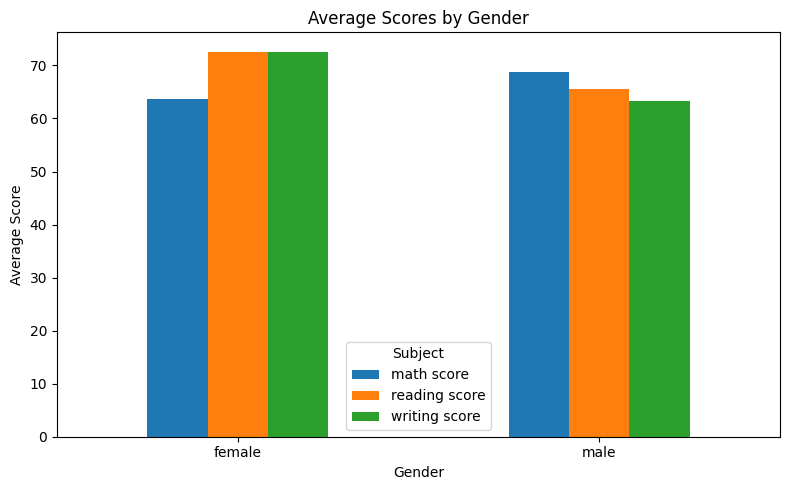

In [44]:
gender_scores.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Average Scores by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Score")
plt.xticks(rotation=0)
plt.legend(title="Subject")

plt.tight_layout()
plt.show()

In [45]:
race_scores = df.groupby(
    "race/ethnicity"
)[score_columns].mean()

print(race_scores)

                math score  reading score  writing score
race/ethnicity                                          
group A          61.629213      64.674157      62.674157
group B          63.452632      67.352632      65.600000
group C          64.463950      69.103448      67.827586
group D          67.362595      70.030534      70.145038
group E          73.821429      73.028571      71.407143


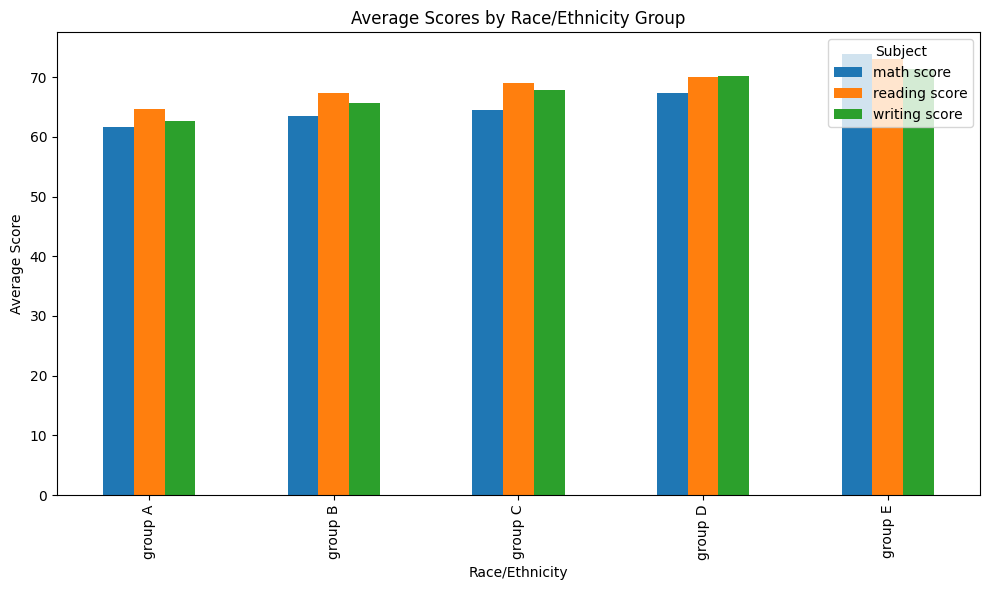

In [46]:
race_scores.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Average Scores by Race/Ethnicity Group")
plt.xlabel("Race/Ethnicity")
plt.ylabel("Average Score")
plt.legend(title="Subject")

plt.tight_layout()
plt.show()

In [47]:
print("Average Math Score:", df["math score"].mean())
print("Average Reading Score:", df["reading score"].mean())
print("Average Writing Score:", df["writing score"].mean())
print("Average Total Score:", df["Total Score"].mean())
print("Average Percentage:", df["Percentage Performance"].mean())

Average Math Score: 66.089
Average Reading Score: 69.169
Average Writing Score: 68.054
Average Total Score: 203.312
Average Percentage: 67.77066666666666


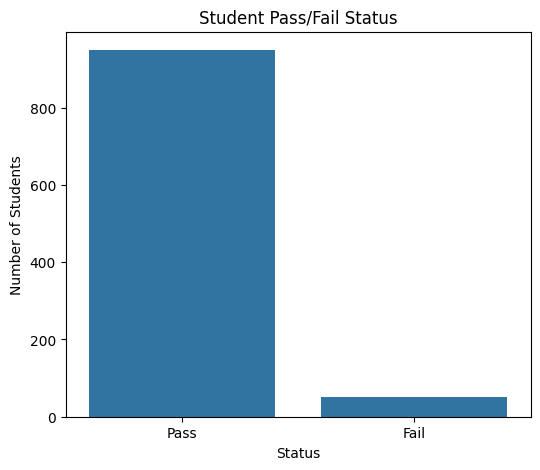

In [48]:
pass_counts = df["Pass/Fail Status"].value_counts()

plt.figure(figsize=(6, 5))

sns.barplot(
    x=pass_counts.index,
    y=pass_counts.values
)

plt.title("Student Pass/Fail Status")
plt.xlabel("Status")
plt.ylabel("Number of Students")

plt.show()

In [49]:
test_prep_analysis = df.groupby(
    "test preparation course"
)[
    ["math score", "reading score", "writing score",
     "Total Score", "Average Score", "Percentage Performance"]
].mean()

print(test_prep_analysis)

                         math score  reading score  writing score  \
test preparation course                                             
completed                 69.695531      73.893855      74.418994   
none                      64.077882      66.534268      64.504673   

                         Total Score  Average Score  Percentage Performance  
test preparation course                                                      
completed                 218.008380      72.669460               72.669460  
none                      195.116822      65.038941               65.038941  


In [50]:
print(df.head())
print("\nShape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  \
0                    none          72             72             74   
1               completed          69             90             88   
2                    none          90             95             93   
3                    none          47             57             44   
4                    none          76             78             75   

   Total Score  Average Score  Percentage Performance Pass/Fail Status  
0          218      72.666667               72.666667             Pass  
1     

## Business Insights Report
## Student Performance Data Analysis

### 1. Introduction

The Student Performance dataset contains information about students' demographic characteristics, parental education, lunch type, test preparation status, and examination scores in **Math, Reading, and Writing**.

The purpose of this analysis is to understand overall academic performance, identify differences across demographic and socioeconomic groups, evaluate the relationship between test preparation and academic outcomes, and identify relationships among the three subjects.

The analysis uses descriptive statistics, grouped comparisons, box plots, scatter plots, and correlation analysis.

---

# 2. Overall Performance

### Which subject has the highest average score?

The **Reading** subject has the highest average score.

| Subject | Average Score |
|---|---:|
| Math | 66.09 |
| Reading | **69.17** |
| Writing | 68.05 |

Therefore, Reading has the highest average performance among the three subjects.

### Which subject has the lowest average score?

**Math** has the lowest average score at **66.09**.

### What is the average overall student performance?

The overall average score across Math, Reading, and Writing is approximately:

**67.77 / 100**

The average total score across the three subjects is approximately:

**203.31 / 300**

### Which subject shows the greatest variation?

Based on standard deviation:

| Subject | Standard Deviation |
|---|---:|
| Math | 15.16 |
| Reading | 14.60 |
| Writing | **15.20** |

**Writing** shows the greatest variation, although its variation is only slightly higher than Math.

### Are the score distributions similar?

The three subjects have fairly similar distributions because their standard deviations are close:

- Math: 15.16
- Reading: 14.60
- Writing: 15.20

However, Reading has a slightly lower spread, while Writing has the highest spread.

**Insight:** Students perform relatively similarly across the three subjects, but Math has the lowest average while Reading has the highest.

---

# 3. Parental Level of Education

The average scores were compared across different parental education levels.

| Parental Education | Math | Reading | Writing |
|---|---:|---:|---:|
| Associate's Degree | 67.88 | 70.93 | 69.90 |
| Bachelor's Degree | 69.39 | 73.00 | 73.38 |
| High School | 62.14 | 64.70 | 62.45 |
| Master's Degree | **69.75** | **75.37** | **75.68** |
| Some College | 67.13 | 69.46 | 68.84 |
| Some High School | 63.50 | 66.94 | 64.89 |

### How does average performance vary?

Students whose parents have **Master's degrees** show the highest average performance across all three subjects.

Students whose parents have only a **High School education** show comparatively lower average scores.

### Which group has the highest average scores?

The **Master's Degree** group has the highest scores:

- Math: 69.75
- Reading: 75.37
- Writing: 75.68

### Which subject shows the largest variation across parental education groups?

The range between the highest and lowest group averages is:

- Math: 7.61
- Reading: 10.67
- Writing: **13.23**

Therefore, **Writing shows the largest variation** across parental education groups.

### Are there noticeable differences?

Yes. The results show noticeable differences in average academic performance across parental education groups.

The High School group has relatively lower averages, while the Master's Degree group has relatively higher averages.

**Important:** This describes an association in this dataset; it does not establish that parental education directly causes differences in student performance.

---

# 4. Lunch Type

The dataset contains two lunch categories:

- Standard
- Free/Reduced

| Lunch Type | Math | Reading | Writing |
|---|---:|---:|---:|
| Free/Reduced | 58.92 | 64.65 | 63.02 |
| Standard | **70.03** | **71.65** | **70.82** |

### How does performance vary across lunch categories?

Students in the **Standard lunch** group have higher average scores in all three subjects.

### Which lunch group has the higher average score?

The **Standard lunch** group has the higher average performance.

Differences between Standard and Free/Reduced groups are:

- Math: **11.11 points**
- Reading: **7.00 points**
- Writing: **7.80 points**

### Are differences consistent?

Yes. The Standard group has higher averages in:

- Math
- Reading
- Writing

The largest difference occurs in **Math**.

### What do the box plots and bar charts show?

The bar charts show a clear difference in average scores between the two lunch categories.

The box plots can additionally show:
- median differences
- score spread
- overlapping distributions
- unusually low or high observations

**Educational insight:** Lunch category appears to be associated with academic performance in this dataset. Because lunch status may reflect socioeconomic circumstances, this pattern may warrant further investigation into access to educational resources and support.

---

# 5. Test Preparation

Test preparation is divided into:

- Completed
- None

| Test Preparation | Math | Reading | Writing |
|---|---:|---:|---:|
| Completed | **69.70** | **73.89** | **74.42** |
| None | 64.08 | 66.53 | 64.50 |

### How do students compare?

Students who **completed the test preparation course** have higher average scores in all three subjects.

### Which subject has the largest difference?

The differences are:

- Math: 5.62
- Reading: 7.36
- Writing: **9.91**

Therefore, **Writing shows the largest difference** between the two groups.

### How does Total Score vary?

| Test Preparation | Average Total Score |
|---|---:|
| Completed | **218.01 / 300** |
| None | 195.12 / 300 |

The difference is approximately **22.89 points**.

### How does Average Score vary?

| Test Preparation | Average Score |
|---|---:|
| Completed | **72.67** |
| None | 65.04 |

The difference is approximately **7.63 points**.

### What does the box plot reveal?

The box plots can show that the test-preparation groups have different score distributions, including differences in median, spread, and possible outliers.

The completed group generally has higher scores.

### Can this be interpreted as causation?

**No.**

This dataset is observational. The higher scores among students who completed test preparation show an **association**, but they do not prove that the preparation course itself caused the higher scores.

Other factors may influence the results, such as:

- prior academic performance
- study habits
- family background
- motivation
- access to educational resources

---

# 6. Gender Analysis

| Gender | Math | Reading | Writing |
|---|---:|---:|---:|
| Female | 63.63 | **72.61** | **72.47** |
| Male | **68.73** | 65.47 | 63.31 |

### How do scores vary?

Female students have higher average:

- Reading
- Writing

Male students have higher average:

- Math

### Which subject has the largest difference?

The approximate differences are:

- Math: 5.10
- Reading: 7.14
- Writing: **9.16**

Writing shows the largest gender-group difference.

These differences should be treated as descriptive patterns rather than explanations of why students perform differently.

---

# 7. Race/Ethnicity Analysis

| Group | Math | Reading | Writing |
|---|---:|---:|---:|
| Group A | 61.63 | 64.67 | 62.67 |
| Group B | 63.45 | 67.35 | 65.60 |
| Group C | 64.46 | 69.10 | 67.83 |
| Group D | 67.36 | 70.03 | 70.15 |
| Group E | **73.82** | **73.03** | **71.41** |

### How do scores vary?

There are noticeable differences in average scores across race/ethnicity groups.

Group E has the highest Math average, while Group D has the highest Writing average among the groups except Group E, which remains highest overall for the three-subject average pattern.

Group A has comparatively lower average scores.

### Which subjects show the largest differences?

The range between the highest and lowest group averages is:

- Math: **12.19**
- Reading: 8.35
- Writing: 8.73

Therefore, **Math shows the largest difference across race/ethnicity groups**.

### Which groups require further investigation?

Groups with comparatively lower average scores could be considered for **further investigation and additional academic support**, rather than being assumed to have an inherent academic disadvantage.

The analysis should be followed by investigation of factors such as:

- access to resources
- socioeconomic conditions
- school environment
- test preparation
- previous academic achievement

---

# 8. Subject Relationships

The correlation matrix is:

| | Math | Reading | Writing |
|---|---:|---:|---:|
| Math | 1.000 | 0.818 | 0.803 |
| Reading | 0.818 | 1.000 | **0.955** |
| Writing | 0.803 | **0.955** | 1.000 |

### Math and Reading

Math and Reading have a strong positive correlation:

**0.818**

Students with higher Math scores generally also tend to have higher Reading scores.

### Math and Writing

Math and Writing have a strong positive correlation:

**0.803**

### Reading and Writing

Reading and Writing have the strongest correlation:

**0.955**

This indicates a very strong positive relationship between Reading and Writing scores.

### Which pair has the strongest correlation?

**Reading and Writing — 0.955**

### What does the correlation heatmap indicate?

The heatmap shows strong positive relationships among all three subjects.

The strongest relationship is between:

**Reading ↔ Writing**

This suggests that students who perform well in Reading generally also perform well in Writing.

However, correlation does not establish causation.

---

# 9. Major Educational Insights

### Overall Performance

The overall average performance is approximately **67.77/100**.

Reading has the highest average score, while Math has the lowest.

### Demographic Factors

Noticeable differences are observed across:

- parental education
- lunch category
- gender
- race/ethnicity

These variables are associated with differences in average scores, but the dataset alone does not establish the underlying causes.

### Test Preparation

Students who completed test preparation have higher average scores across all three subjects.

The largest difference is observed in **Writing**, followed by Reading and Math.

### Subject Relationships

All three subjects are strongly positively correlated.

The strongest correlation is between **Reading and Writing (0.955)**.

---

# 10. Areas Requiring Further Investigation

The following areas could be investigated further:

### 1. Math Performance

Math has the lowest overall average score, so additional analysis could examine factors associated with lower Math performance.

### 2. Socioeconomic Differences

The difference between Standard and Free/Reduced lunch groups suggests that socioeconomic factors may be relevant to academic outcomes.

### 3. Test Preparation

Further analysis could investigate whether test preparation remains associated with higher scores after accounting for other student characteristics.

### 4. Parental Education

The variation across parental education groups suggests that educational background may be associated with student outcomes.

### 5. Gender Differences

The subject-specific gender patterns—higher average Math for males and higher Reading/Writing averages for females—could be explored further.

### 6. Race/Ethnicity Differences

Differences among race/ethnicity groups warrant careful investigation using additional contextual variables rather than interpreting group averages in isolation.

---

# 11. Recommendations

Based on the observed patterns, the following **data-informed recommendations** can be proposed:

1. **Strengthen Math support programs** because Math has the lowest overall average score.

2. **Provide targeted academic support** for groups with comparatively lower observed performance, while investigating the underlying factors before designing interventions.

3. **Expand access to test-preparation resources**, particularly for students who may not otherwise have access to such support.

4. **Investigate socioeconomic factors** associated with the differences between Standard and Free/Reduced lunch groups.

5. **Support Reading and Writing development**, given their very strong correlation.

6. **Conduct further analysis using additional variables** such as attendance, previous academic performance, study time, school resources, and socioeconomic indicators.

7. **Avoid treating demographic group averages as causal explanations.** Group differences should be used as signals for further investigation rather than assumptions about individual students.

---

# 12. Conclusion

The EDA of the Student Performance dataset reveals several important patterns. The overall average student performance is approximately **67.77**, with Reading having the highest average score and Math having the lowest. Writing shows the greatest overall score variation.

Parental education and lunch category are associated with noticeable differences in academic performance. Students in the Standard lunch group have higher average scores than those in the Free/Reduced group. Students who completed test preparation also show higher average scores across all three subjects, although this observational dataset cannot establish that test preparation caused the difference.

Gender and race/ethnicity comparisons reveal additional differences across subjects. Finally, all three subjects demonstrate strong positive correlations, with **Reading and Writing showing the strongest relationship (0.955)**.

Overall, the analysis provides useful evidence for identifying patterns and areas that may require further educational investigation. These findings can support data-informed planning while recognizing that additional data and statistical analysis would be required before drawing causal conclusions.